**Figure settings** 

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from matplotlib.ticker import MaxNLocator
from astropy.coordinates import SkyCoord
from astropy import units as u

G=6.67*10**(-11)
Ms=1.989*10**(30)
c=3*10**8
pc=3.26*9.46*10**15
yr=3600*24*365

def radius(M,T):
    return (G*M*T**2/(4*np.pi**2))**(1/3)

def vcratio(M,T):
    return (G*M/radius(M,T))**(1/2)/c

font_size=8.0
label_font_size=6.0

plt.rcParams.update({
    'figure.figsize':(3.3465,2.5),

    'font.size':font_size,
    'axes.titlesize':font_size,
    'axes.labelsize':font_size,
    'xtick.labelsize':font_size-2,
    'ytick.labelsize':font_size-2,
    'legend.fontsize':font_size,
    'legend.title_fontsize':font_size,

    'lines.linewidth':1.0,
    'axes.linewidth':0.6,
    'grid.linewidth':0.5,
    'contour.linewidth': 0.6,

    'lines.markersize':3.0,
    'lines.markeredgewidth':0.5,


    'xtick.major.width':0.6,
    'ytick.major.width':0.6,
    'xtick.minor.width':0.4,
    'ytick.minor.width':0.4,
    'xtick.major.size':3.0,
    'ytick.major.size':3.0,
    'xtick.minor.size':1.5,
    'ytick.minor.size':1.5,



    'figure.dpi':600,
    'savefig.dpi':600,
    'savefig.format':'pdf',
    'savefig.bbox':'tight',

    'legend.frameon':True,


})

figure_dir = 'Figure'
if not os.path.exists(figure_dir):
    os.makedirs(figure_dir)
data_dir='Numerical_Data'

**RESULTS**

**A. Near Field Effects**

A1. Integrand $\tilde{r}_{1,2}$

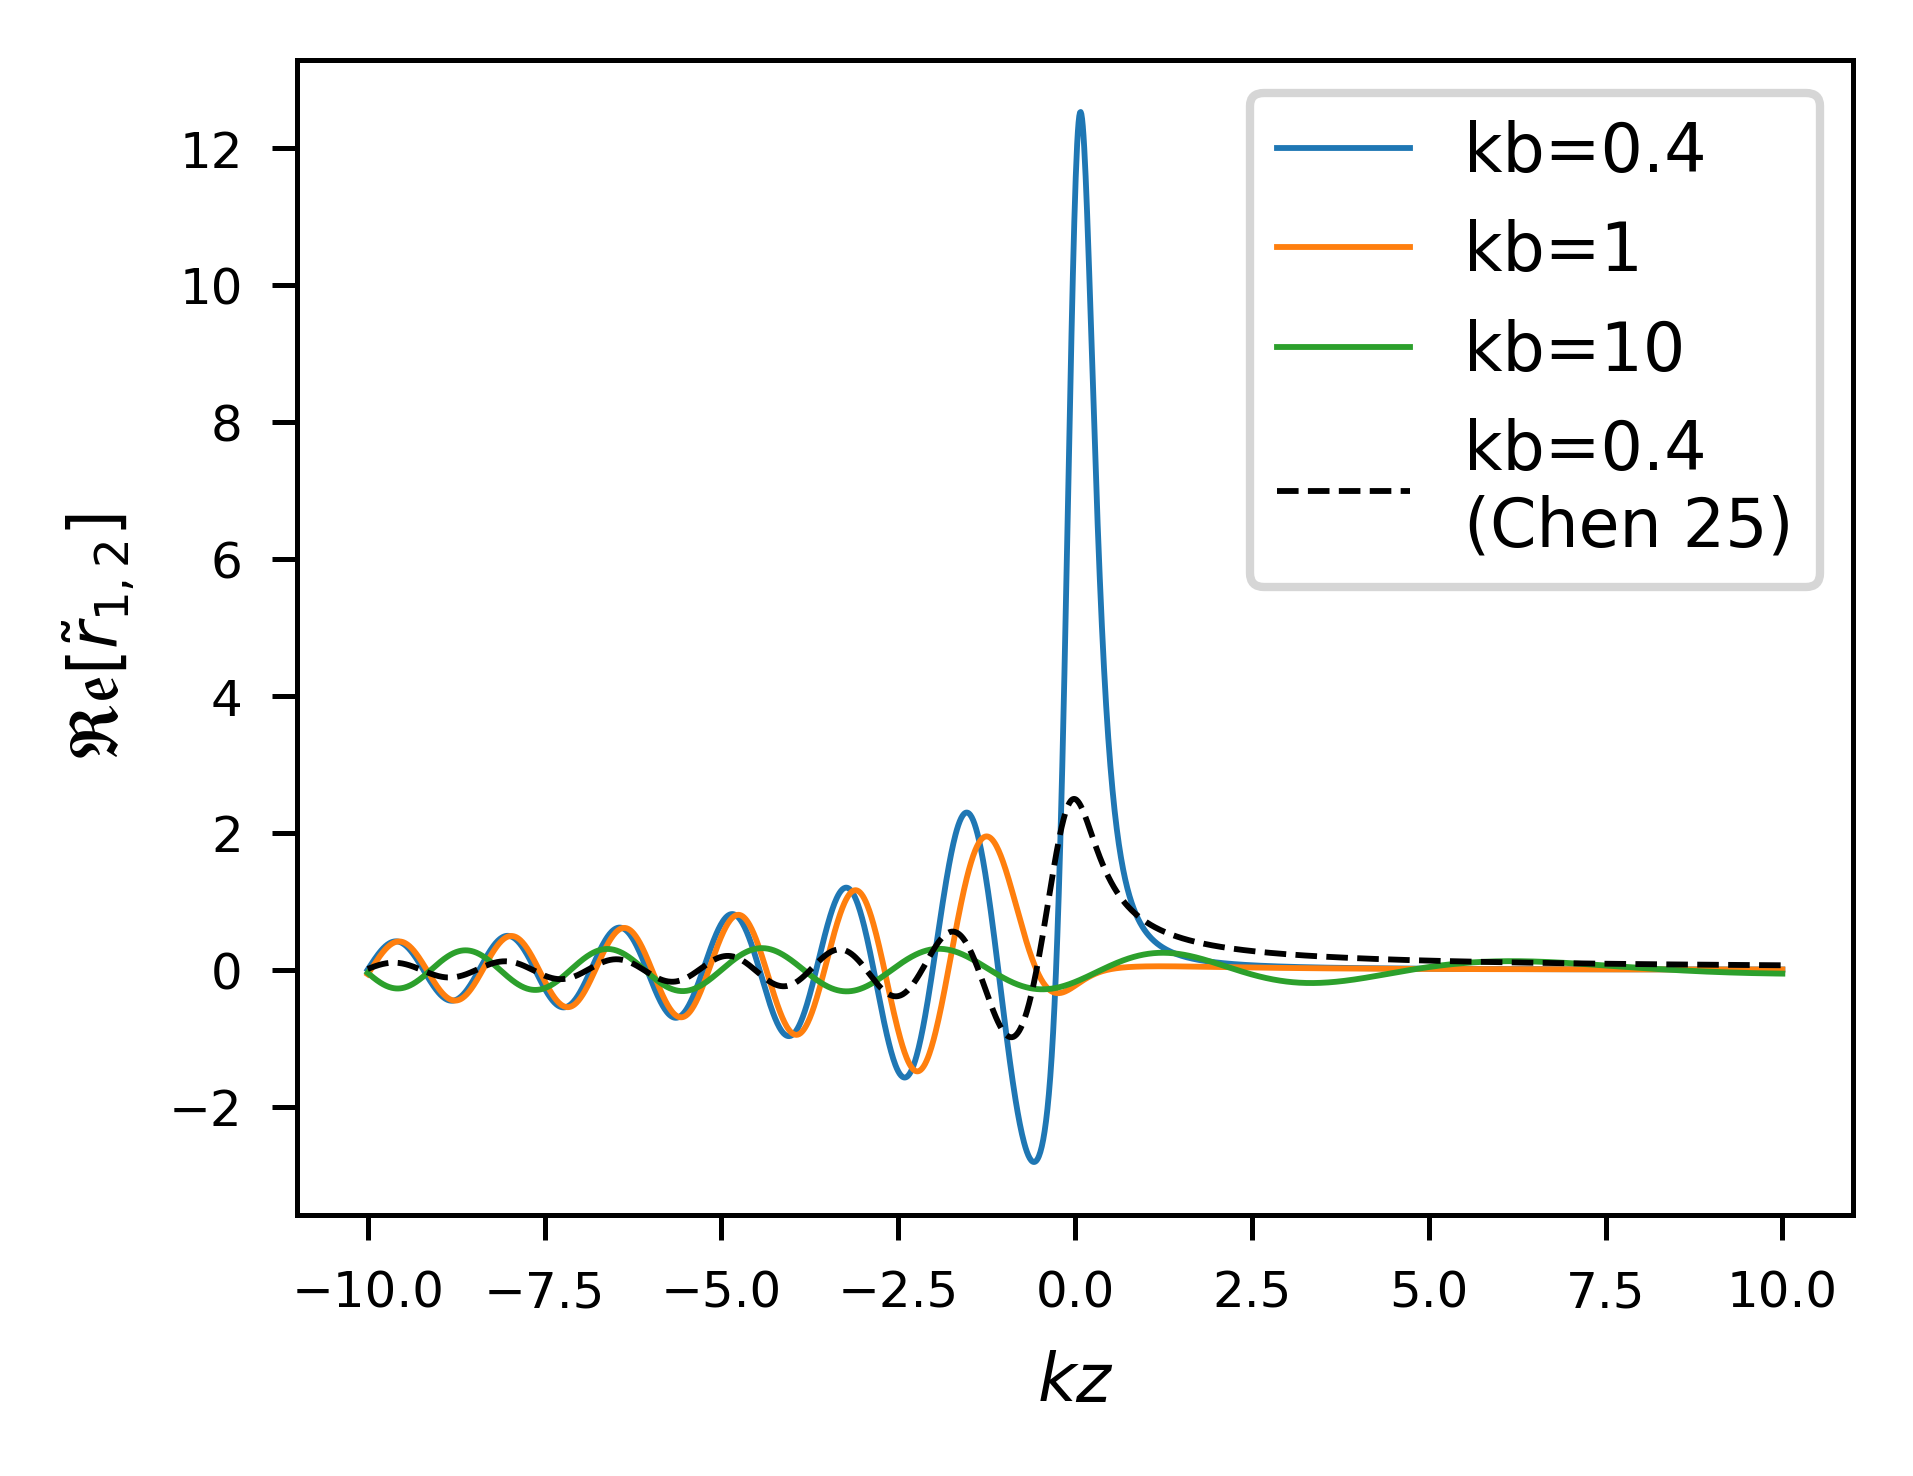

In [50]:
r1integrand1=pd.read_csv(os.path.join(data_dir, 'r1integrand1.csv'),header=None)
r1integrand2=pd.read_csv(os.path.join(data_dir, 'r1integrand2.csv'),header=None)
r1integrand3=pd.read_csv(os.path.join(data_dir, 'r1integrand3.csv'),header=None)
r1integrandold=pd.read_csv(os.path.join(data_dir, 'r1integrandold.csv'),header=None)
x=r1integrand2[0].values    
y1=r1integrand1[1].values
y2=r1integrand2[1].values
y3=r1integrand3[1].values
yold=r1integrandold[1].values
plt.plot(x,y1,label="kb=0.4",linewidth=0.7)
plt.plot(x,y2,label="kb=1",linewidth=0.7)
plt.plot(x,y3,label="kb=10",linewidth=0.7)
plt.plot(x,yold,linestyle='--',color='black',label="kb=0.4\n(Chen 25)",linewidth=0.7)
plt.xlabel(r'$kz$')
plt.ylabel(r'$\mathfrak{Re}[\tilde{r}_{1,2}]$')
plt.legend()
plt.savefig(os.path.join(figure_dir, 'Re[r12].pdf'))
plt.show()

A2. Dimensionless $|\tilde{R}_{1,2}|$ and $|\tilde{R}_{2,2}|$

C:\Users\qihou\AppData\Local\Temp\ipykernel_16660\266804921.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


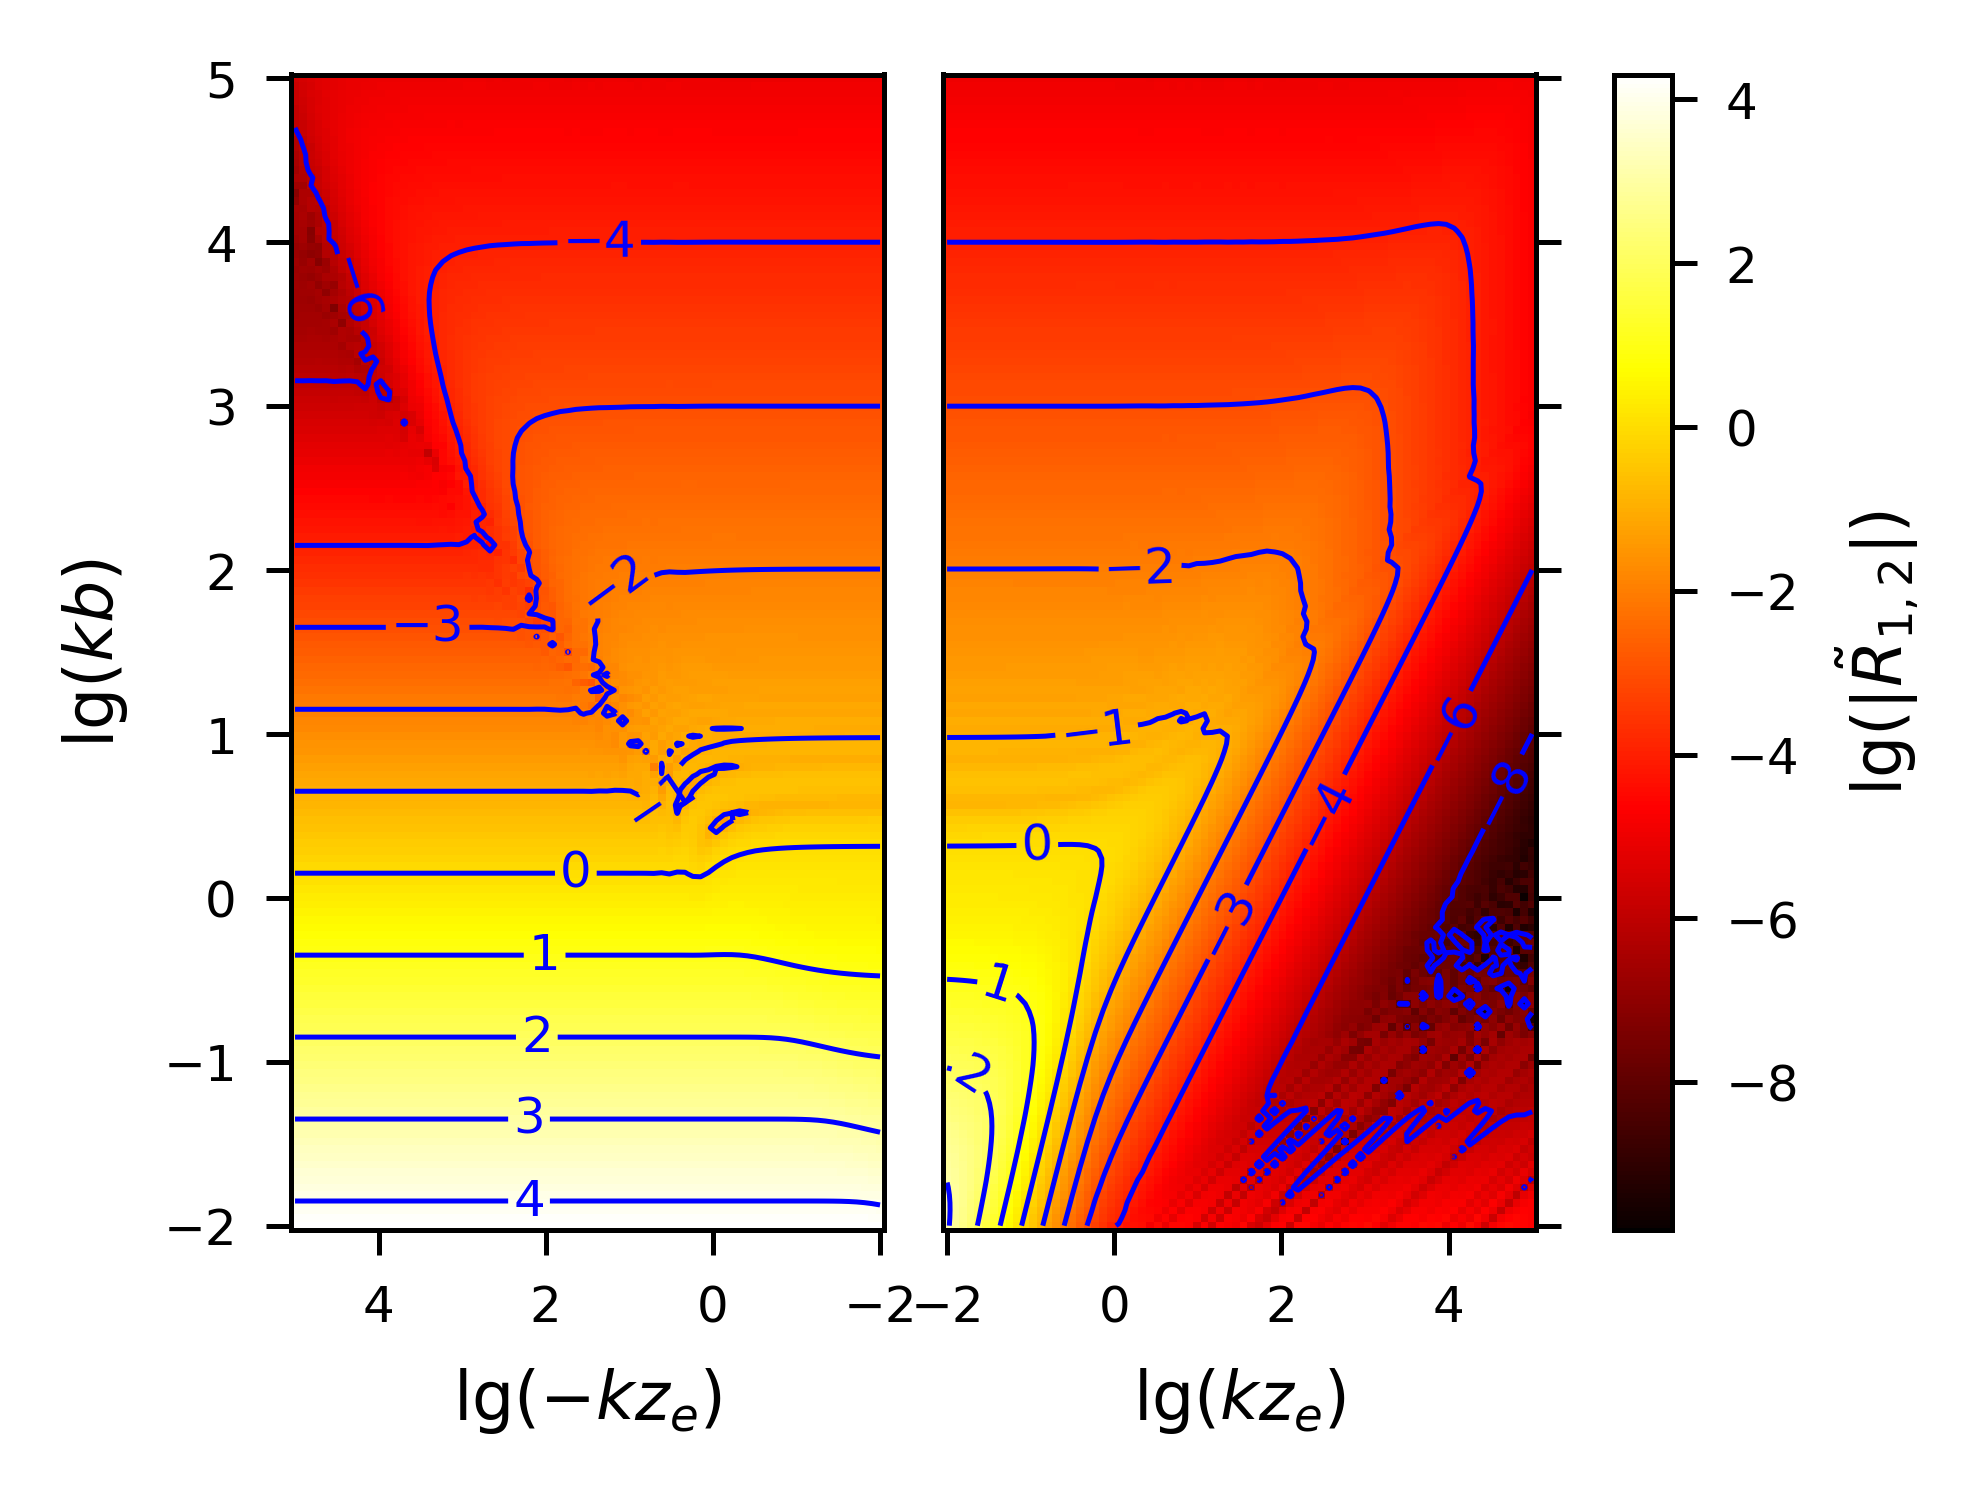

C:\Users\qihou\AppData\Local\Temp\ipykernel_16660\266804921.py:125: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


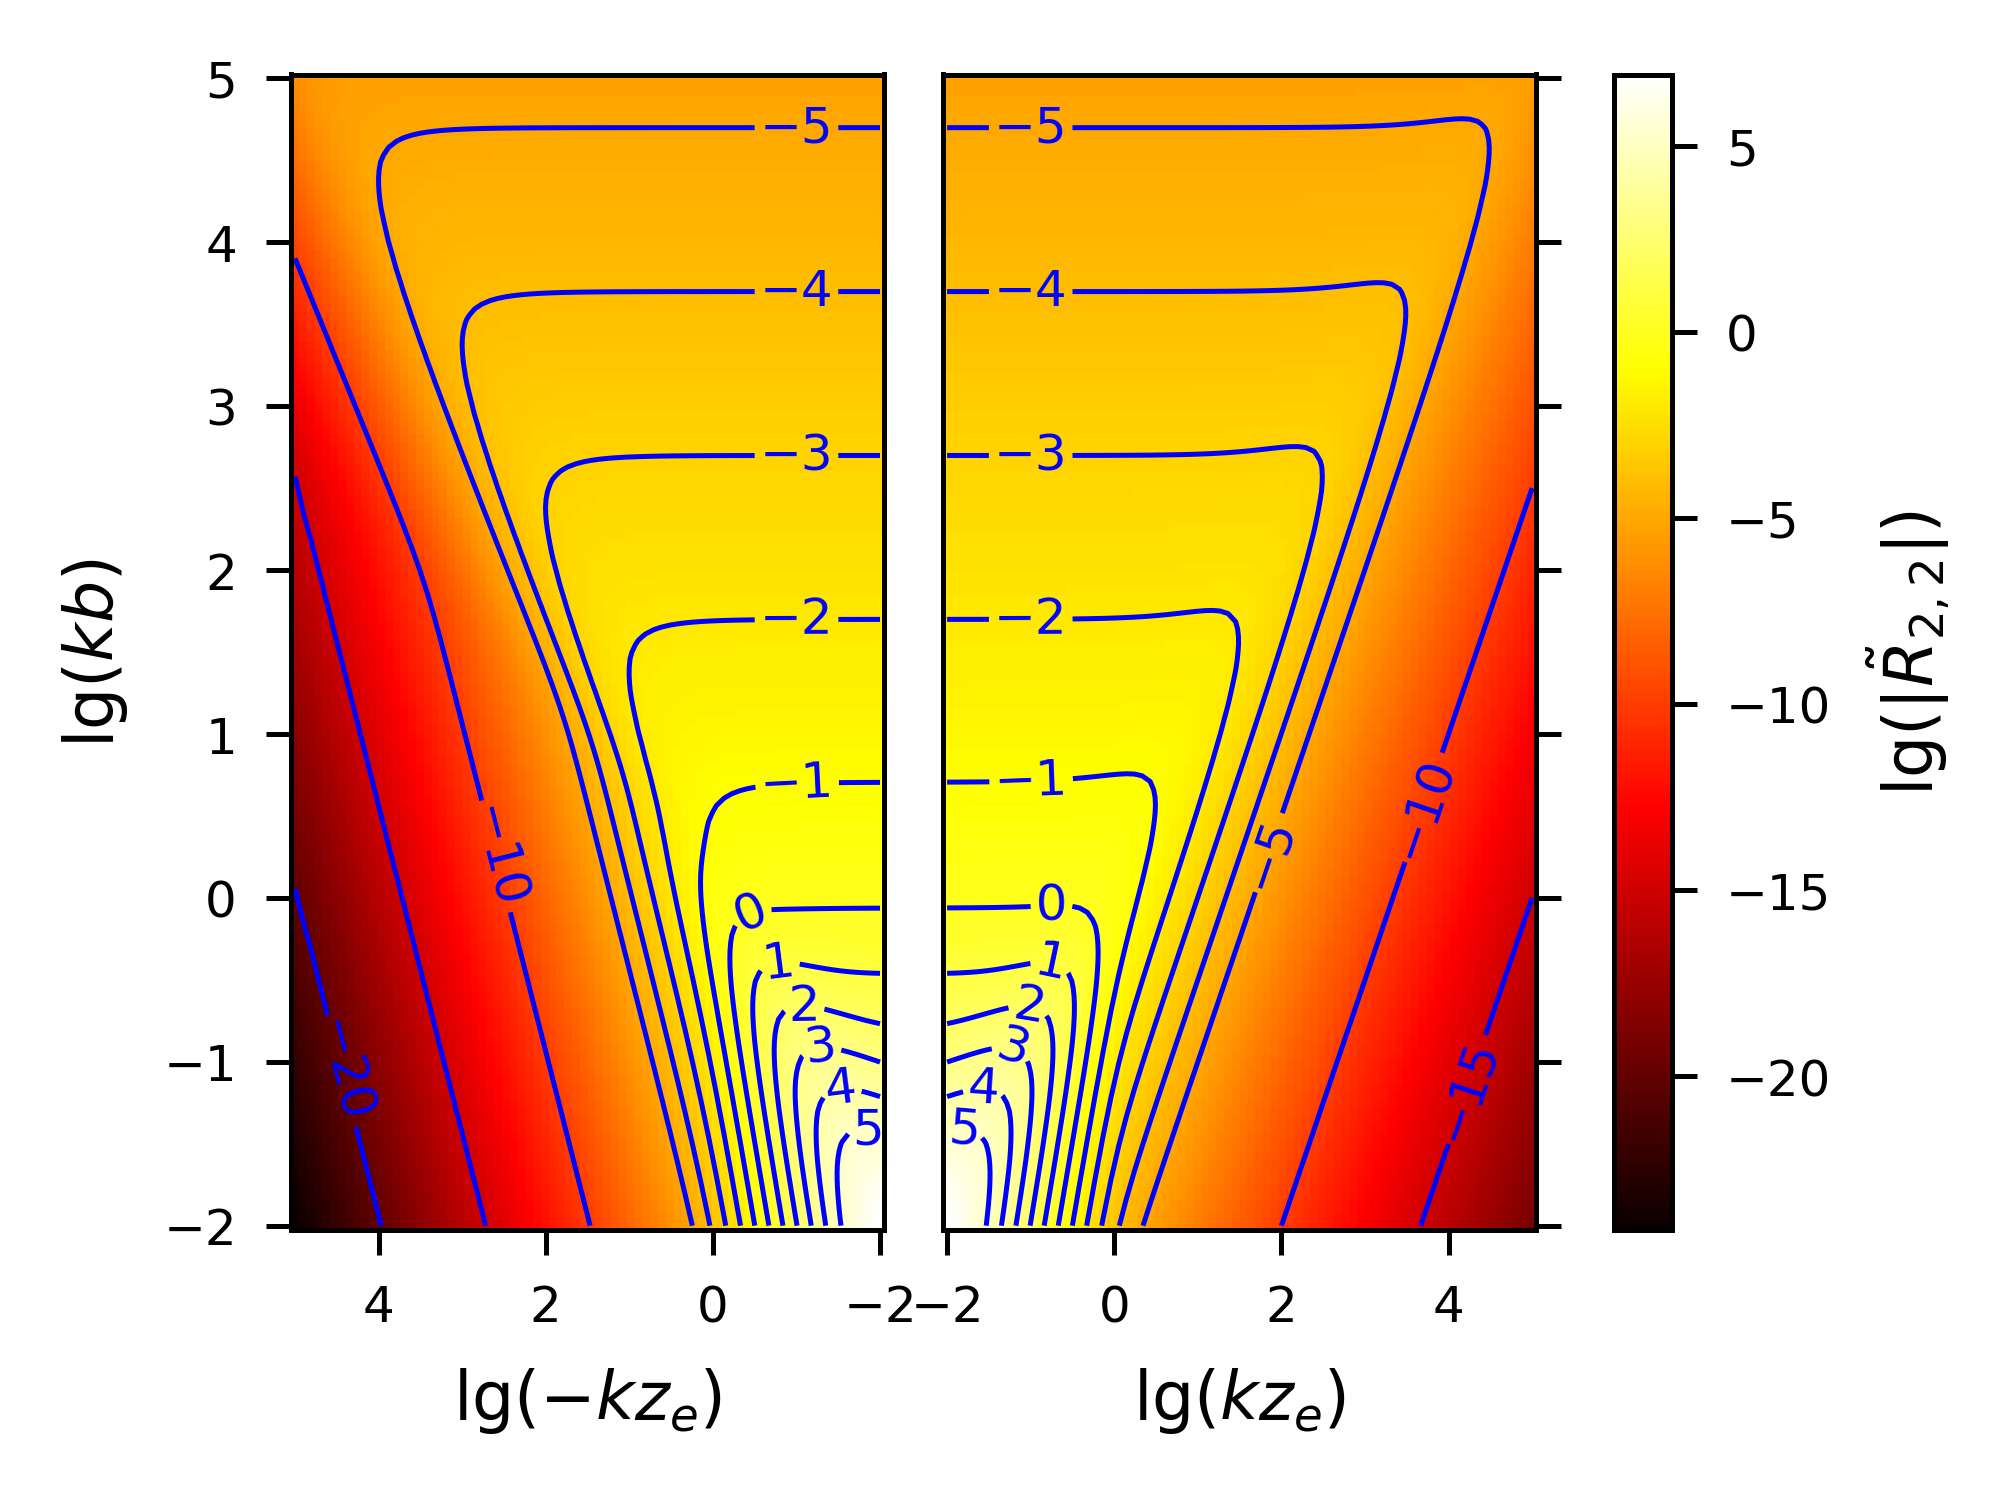

In [51]:
kzsep=pd.read_csv(os.path.join(data_dir, 'kzsep.csv'),header=None)
kbsep=pd.read_csv(os.path.join(data_dir, 'kbsep.csv'),header=None)

r1R=pd.read_csv(os.path.join(data_dir, 'r1R.csv'),header=None)
r1L=pd.read_csv(os.path.join(data_dir, 'r1L.csv'),header=None)
r2L=pd.read_csv(os.path.join(data_dir, 'r2L.csv'),header=None)
r2R=pd.read_csv(os.path.join(data_dir, 'r2R.csv'),header=None)


#Grid
KZsep,KBsep=np.meshgrid(kzsep,kbsep,indexing="ij")

fig,(ax1,ax2)=plt.subplots(1,2,gridspec_kw={'wspace': 0.1})

#Range of color
vmin = np.min([r1L.values.min(), r1R.values.min()])
vmax = np.max([r1L.values.max(), r1R.values.max()])
norm = plt.Normalize(vmin=vmin, vmax=vmax)

im2 = ax2.pcolormesh(KZsep, KBsep, r1R, cmap="hot", norm=norm)
im1 = ax1.pcolormesh(KZsep, KBsep, r1L, cmap="hot", norm=norm)

ax1.invert_xaxis()

ax1.xaxis.set_major_locator(MaxNLocator(4))  # x轴最多10个主刻度
ax2.xaxis.set_major_locator(MaxNLocator(4))  # 右侧图同样设置


cbar = fig.colorbar(im1, ax=[ax1, ax2],location='right')
for ax in fig.get_axes():
    ax.label_outer()

ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

cs1=ax1.contour(KZsep,KBsep,r1L,colors="blue",linestyles="solid",levels=[-8,-6,-4,-3,-2,-1,0,1,2,3,4])
cs2=ax2.contour(KZsep,KBsep,r1R,colors="blue",linestyles="solid",levels=[-8,-6,-4,-3,-2,-1,0,1,2,3,4])
manual_Locations=[
    (4.68,0.64),
    (3.98,1.05),
    (2.47,0.54),
    (1.32,-0.14),
    (0.31,2.03),
    (-0.21,1.04),
    (-0.92,0.3),
    (-1.39,-0.53),
    (-1.7,-1.08),
]

ax1.clabel(cs1,fontsize=label_font_size)
ax2.clabel(cs2,manual=manual_Locations,fontsize=label_font_size)

#plt.subplots_adjust(wspace=0.2)   
ax1.set_xlabel(r'$\lg(-kz_e)$')
ax1.set_ylabel(r'$\lg(kb)$')
ax2.set_xlabel(r'$\lg(kz_e)$')
cbar.set_label(r'$\lg(|\tilde{R}_{1,2}|)$')
plt.legend(frameon=False)
plt.savefig(os.path.join(figure_dir, 'R12.pdf'))
plt.show()


fig,(ax1,ax2)=plt.subplots(1,2,gridspec_kw={'wspace': 0.1})

vmin = np.min([r2L.values.min(), r2R.values.min()])
vmax = np.max([r2L.values.max(), r2R.values.max()])
norm = plt.Normalize(vmin=vmin, vmax=vmax)

im2 = ax2.pcolormesh(KZsep, KBsep, r2R, cmap="hot", norm=norm)
im1 = ax1.pcolormesh(KZsep, KBsep, r2L, cmap="hot", norm=norm)
ax1.invert_xaxis()

ax1.xaxis.set_major_locator(MaxNLocator(4))  # x轴最多10个主刻度
ax2.xaxis.set_major_locator(MaxNLocator(4))  # 右侧图同样设置

cbar = fig.colorbar(im1, ax=[ax1, ax2],location='right')
for ax in fig.get_axes():
    ax.label_outer()

ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

cs1=ax1.contour(KZsep,KBsep,r2L,colors="blue",linestyles="solid",levels=[-20,-15,-10,-5,-4,-3,-2,-1,0,1,2,3,4,5])
cs2=ax2.contour(KZsep,KBsep,r2R,colors="blue",linestyles="solid",levels=[-20,-15,-10,-5,-4,-3,-2,-1,0,1,2,3,4,5])

manual_Locations=[
    (4,-1),
    (3,0.2),
    (-1,4.8),
    (-1,3.8),
    (-1,2.8),
    (-1,1.8),
    (-1,0.8),
    (-0.4,0),
    (-0.79,-0.41),
    (-1.09,-0.65),
    (-1.29,-0.93),
    (-1.53,-1.14),
    (-1.86,-1.4)
]
ax1.clabel(cs1,manual=manual_Locations,fontsize=label_font_size)
manual_Locations=[
    (4.4,-1.2),
    (4,0.5),
    (2.46,0.17),
    (-1,4.8),
    (-1,3.8),
    (-1,2.8),
    (-1,1.8),
    (-1,0.8),
    (-0.75,-0.06),
    (-0.75,-0.38),
    (-1.02,-0.67),
    (-1.23,-0.94),
    (-1.56,-1.2),
    (-1.8,-1.43)
]
ax2.clabel(cs2,manual=manual_Locations,fontsize=label_font_size)

#plt.subplots_adjust(wspace=0.2)   
ax1.set_xlabel(r'$\lg(-kz_e)$')
ax1.set_ylabel(r'$\lg(kb)$')
ax2.set_xlabel(r'$\lg(kz_e)$')
cbar.set_label(r'$\lg(|\tilde{R}_{2,2}|)$')
plt.legend(frameon=False)
plt.savefig(os.path.join(figure_dir, 'R22.pdf'))
plt.show()

**B. PTA in GCs**

B1. Pulsars in M15, relative distance ranging from $\sim0.05\mathrm{pc}$ to a few $\mathrm{pc}$. 

Mass $M=4000M_{\odot}$, distance $10\mathrm{kpc}$, $q=1$, $P=5\mathrm{yr}$. Core radius $r_c=0.41\mathrm{pc}$. 

Plot range: set $0.05r_c\sim3r_c$, $\theta=\pi/4$

C:\Users\qihou\AppData\Local\Temp\ipykernel_16660\4293770858.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


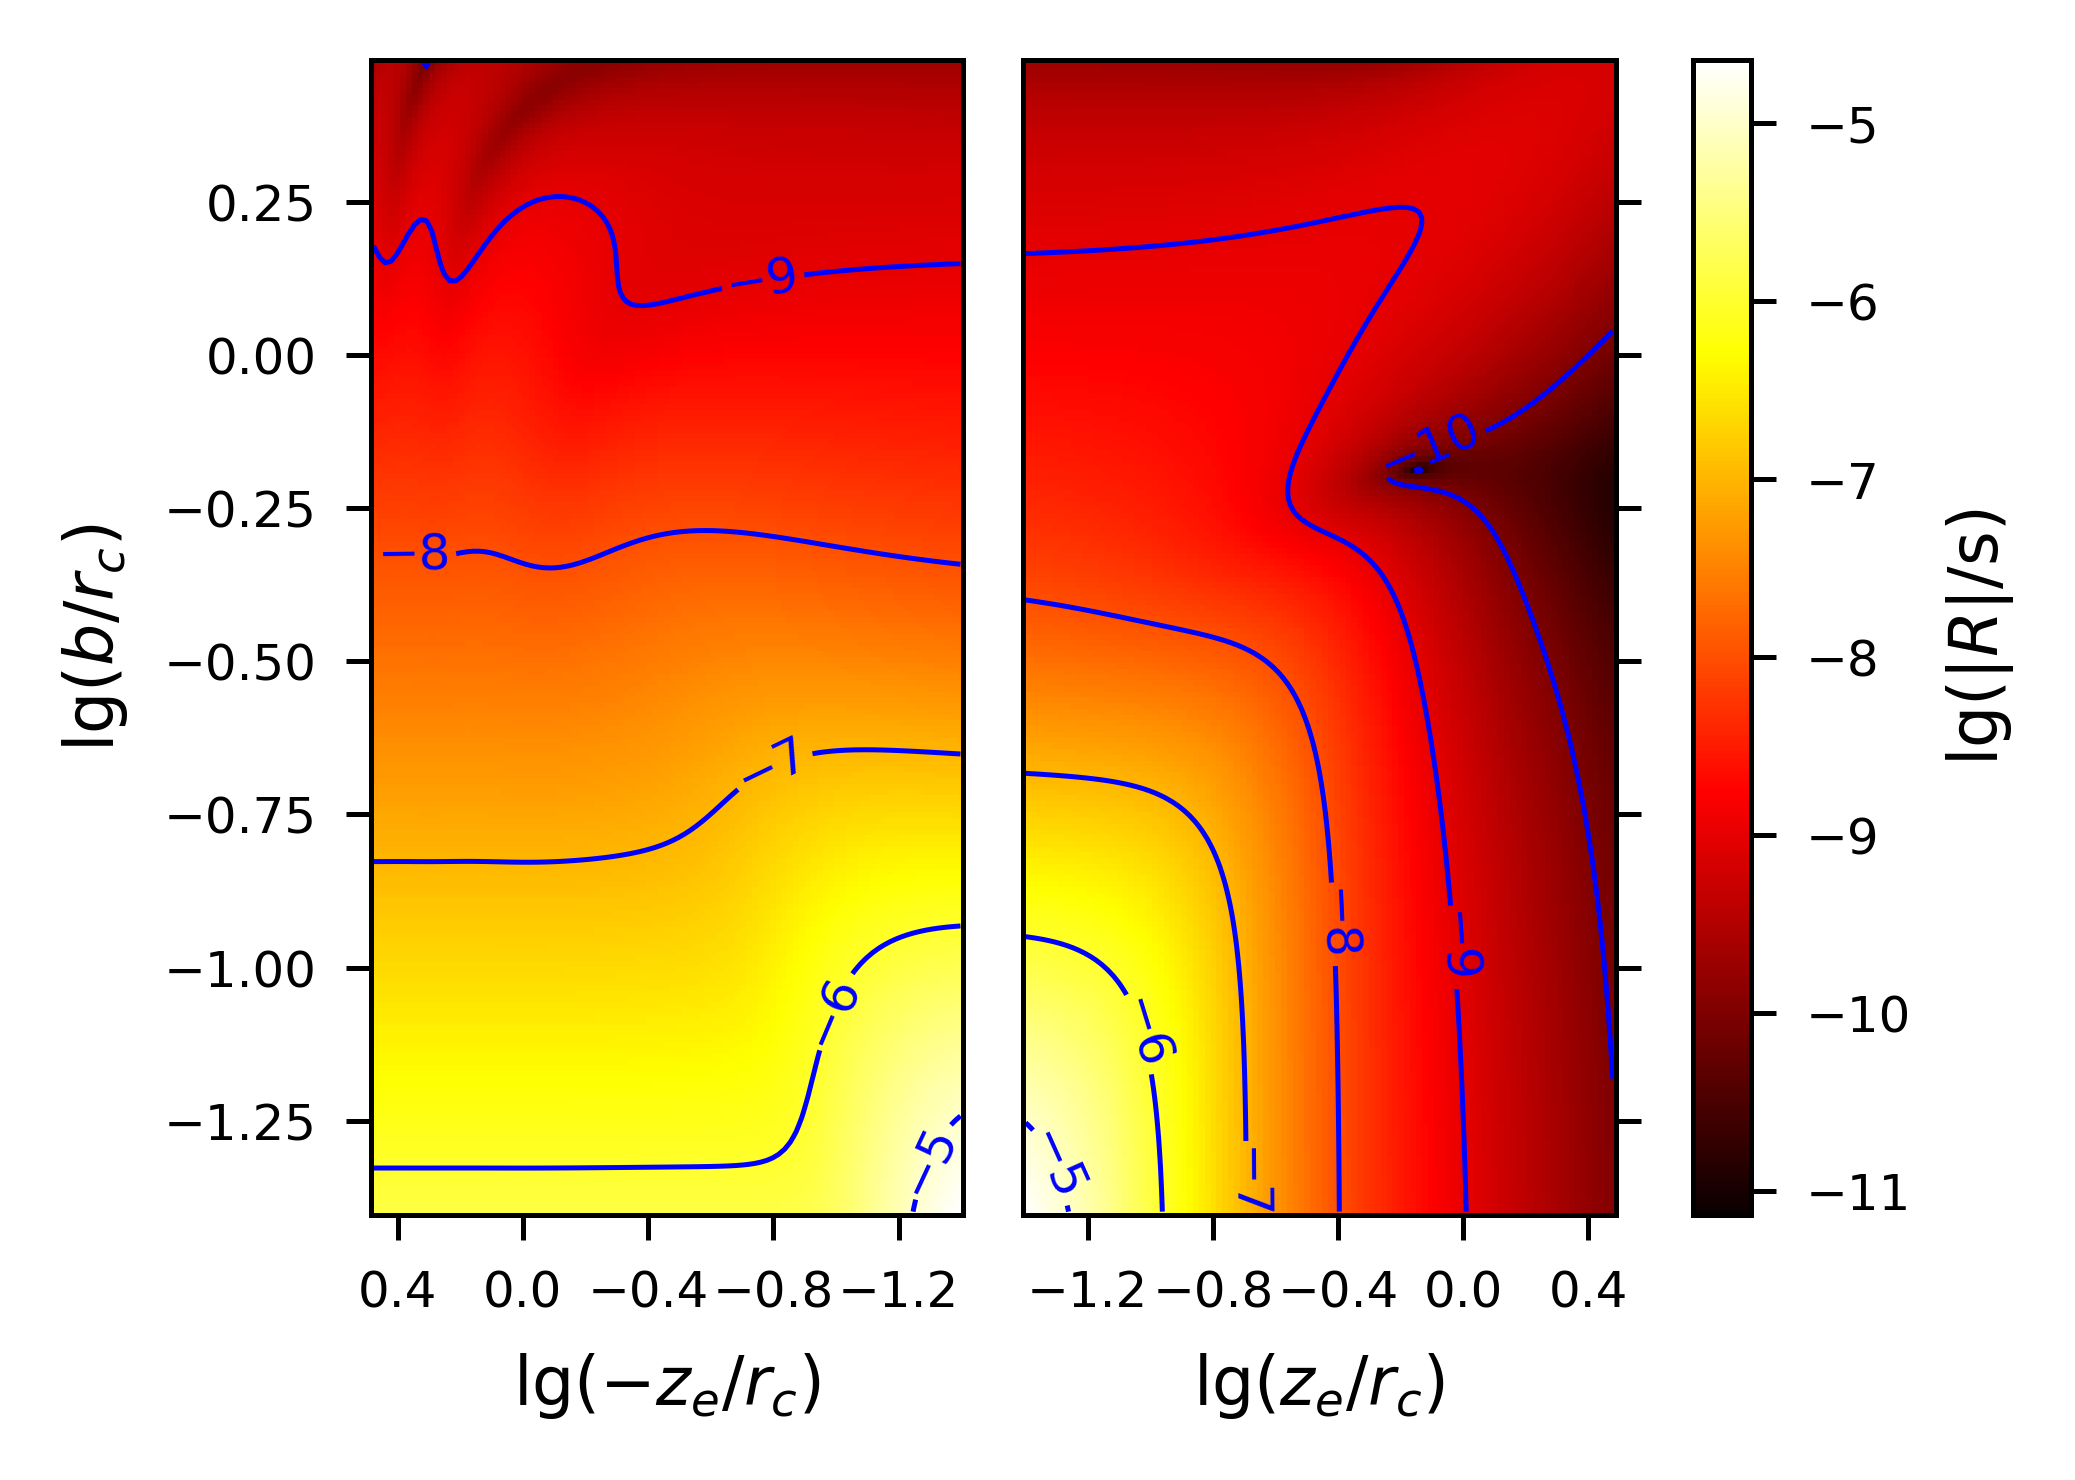

In [52]:
zsep=pd.read_csv(os.path.join(data_dir, 'zsepm15.csv'),header=None)
bsep=pd.read_csv(os.path.join(data_dir, 'bsepm15.csv'),header=None)
rmR=pd.read_csv(os.path.join(data_dir, 'rmRm15.csv'),header=None)
rmL=pd.read_csv(os.path.join(data_dir, 'rmLm15.csv'),header=None)

Zsep,Bsep=np.meshgrid(zsep,bsep,indexing="ij")

fig,(ax1,ax2)=plt.subplots(1,2,gridspec_kw={'wspace': 0.1})

vmin = np.min([rmL.values.min(), rmR.values.min()])
vmax = np.max([rmL.values.max(), rmR.values.max()])
norm = plt.Normalize(vmin=vmin, vmax=vmax)

im2 = ax2.pcolormesh(Zsep, Bsep, rmR, cmap="hot", norm=norm)
im1 = ax1.pcolormesh(Zsep, Bsep, rmL, cmap="hot", norm=norm)
ax1.invert_xaxis()

cbar = fig.colorbar(im1, ax=[ax1, ax2],location='right')
for ax in fig.get_axes():
    ax.label_outer()

ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

cs1=ax1.contour(Zsep,Bsep,rmL,colors="blue",linestyles="solid",levels=[-12,-11,-10,-9,-8,-7,-6,-5,-4])
cs2=ax2.contour(Zsep,Bsep,rmR,colors="blue",linestyles="solid",levels=[-12,-11,-10,-9,-8,-7,-6,-5,-4])
ax1.clabel(cs1,fontsize=label_font_size)
ax2.clabel(cs2,fontsize=label_font_size)

ax1.xaxis.set_major_locator(MaxNLocator(5))  # x轴最多10个主刻度
ax2.xaxis.set_major_locator(MaxNLocator(5))  # 右侧图同样设置

#plt.subplots_adjust(wspace=0.2)   
ax1.set_xlabel(r'$\lg(-z_e/r_{c})$')
ax1.set_ylabel(r'$\lg(b/r_{c})$')
ax2.set_xlabel(r'$\lg(z_e/r_{c})$')
cbar.set_label(r'$\lg(|R|/\mathrm{s})$')
plt.legend(frameon=False)
plt.savefig(os.path.join(figure_dir, 'M15_5yr_q1.pdf'))
plt.show()

B2. Pulsars in $\omega$ Cen. 

Mass $M=10^4M_{\odot}$, distance $5.2\mathrm{kpc}$, $q=1$, $P=5\mathrm{yr}$. Core radius $r_c=3.58\mathrm{pc}$

Plot range: set $0.01r_c\sim3r_c$, $\theta=\pi/4$

C:\Users\qihou\AppData\Local\Temp\ipykernel_16660\2955404970.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


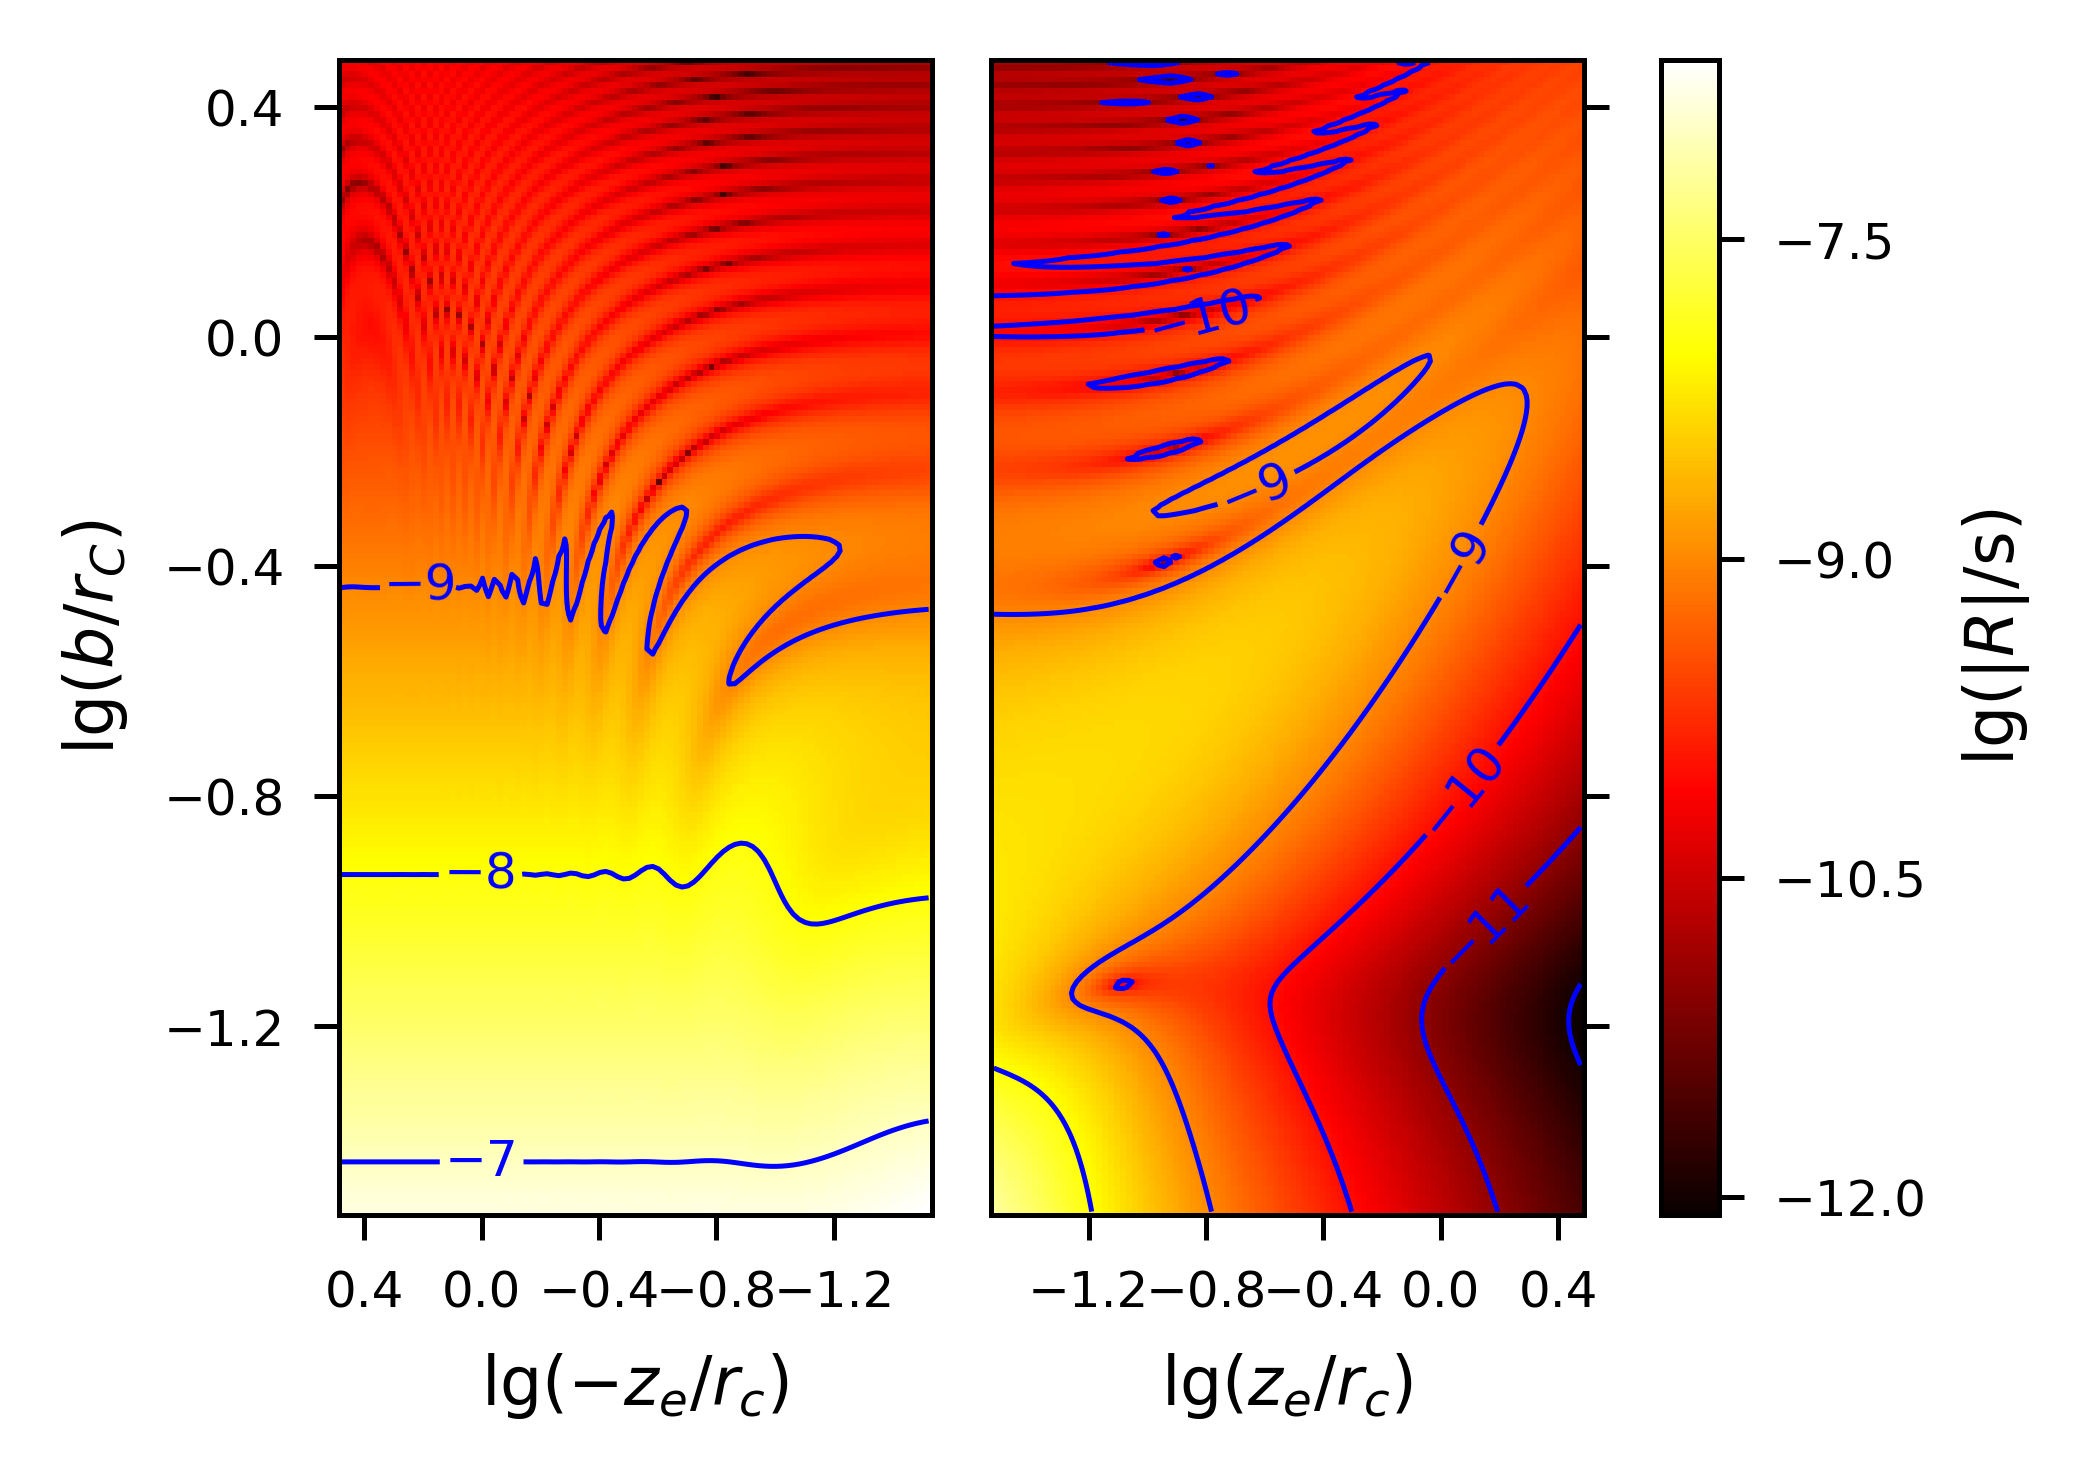

In [53]:
zsep=pd.read_csv(os.path.join(data_dir, 'zsepomegacen.csv'),header=None)
bsep=pd.read_csv(os.path.join(data_dir, 'bsepomegacen.csv'),header=None)
rmR=pd.read_csv(os.path.join(data_dir, 'rmRomegacen.csv'),header=None)
rmL=pd.read_csv(os.path.join(data_dir, 'rmLomegacen.csv'),header=None)

Zsep,Bsep=np.meshgrid(zsep,bsep,indexing="ij")

fig,(ax1,ax2)=plt.subplots(1,2,gridspec_kw={'wspace': 0.1})

vmin = np.min([rmL.values.min(), rmR.values.min()])
vmax = np.max([rmL.values.max(), rmR.values.max()])
norm = plt.Normalize(vmin=vmin, vmax=vmax)

im2 = ax2.pcolormesh(Zsep, Bsep, rmR, cmap="hot", norm=norm)
im1 = ax1.pcolormesh(Zsep, Bsep, rmL, cmap="hot", norm=norm)
ax1.invert_xaxis()

cbar = fig.colorbar(im1, ax=[ax1, ax2],location='right')
for ax in fig.get_axes():
    ax.label_outer()

ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

cs1=ax1.contour(Zsep,Bsep,rmL,colors="blue",linestyles="solid",levels=[-9,-8,-7,-6,-5,-4])
cs2=ax2.contour(Zsep,Bsep,rmR,colors="blue",linestyles="solid",levels=[-12,-11,-10,-9,-8,-7,-6,-5,-4])
manual_Locations=[
    (0.2,-0.4),
    (0,-0.9),
    (0,-1.4)
]
ax1.clabel(cs1,fontsize=label_font_size,manual=manual_Locations)
manual_Locations=[
    (0.1,-1),
    (0.1,-0.8),
    (0.1,-0.4),
    (-0.6,-0.3),
    (-0.8,0)
]
ax2.clabel(cs2,fontsize=label_font_size,manual=manual_Locations)

ax1.xaxis.set_major_locator(MaxNLocator(6))  # x轴最多10个主刻度
ax2.xaxis.set_major_locator(MaxNLocator(6))  # 右侧图同样设置
ax1.yaxis.set_major_locator(MaxNLocator(6))  # x轴最多10个主刻度
ax2.yaxis.set_major_locator(MaxNLocator(6))  # 右侧图同样设置
cbar.ax.yaxis.set_major_locator(MaxNLocator(5))

#plt.subplots_adjust(wspace=0.2)   
ax1.set_xlabel(r'$\lg(-z_e/r_c)$')
ax1.set_ylabel(r'$\lg(b/r_C)$')
ax2.set_xlabel(r'$\lg(z_e/r_c)$')
cbar.set_label(r'$\lg(|R|/\mathrm{s})$')
plt.legend(frameon=False)
plt.savefig(os.path.join(figure_dir, 'OmegaCen_5yr_q1.pdf'))
plt.show()

**D. Pulsars in the Sgr $A^*$**

Mass $M=4\times10^6\,M_{\odot}$, distance $7.9\,\mathrm{kpc}$, $q=10^{-4}$, $P=5\mathrm{yr}$. Plotrange: set $0.1\mathrm{pc}\sim100\mathrm{pc}$, $P=5\mathrm{yr}$

C:\Users\qihou\AppData\Local\Temp\ipykernel_16660\86548093.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


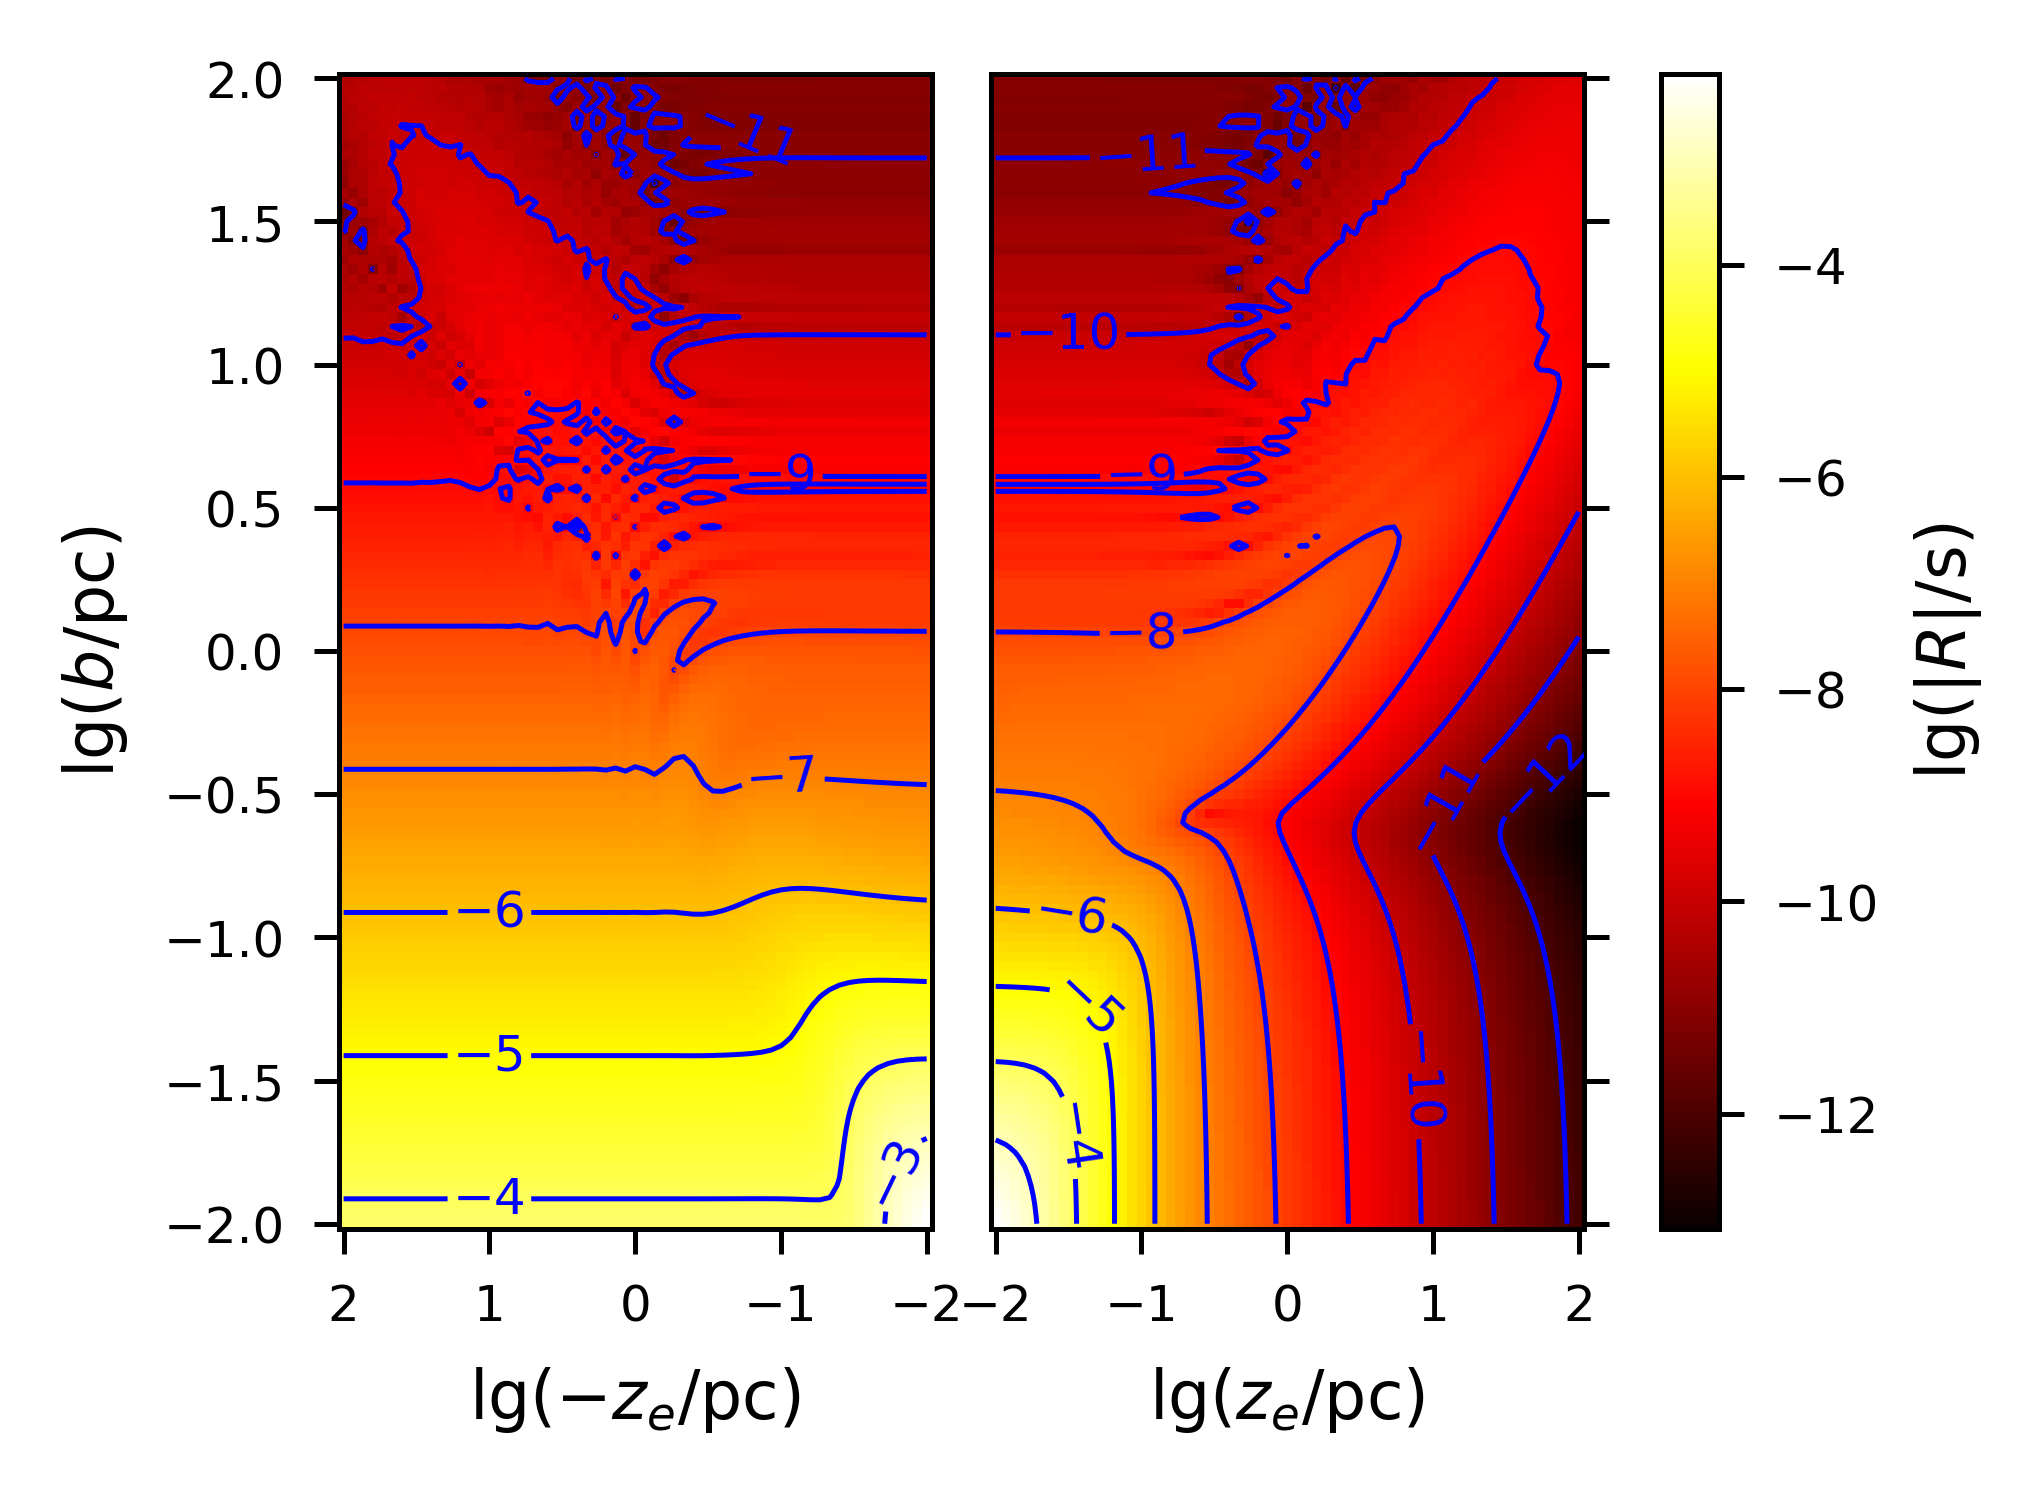

In [54]:
zsep=pd.read_csv(os.path.join(data_dir, 'zsepsgra.csv'),header=None)
bsep=pd.read_csv(os.path.join(data_dir, 'bsepsgra.csv'),header=None)
rmR=pd.read_csv(os.path.join(data_dir, 'rmRsgra.csv'),header=None)
rmL=pd.read_csv(os.path.join(data_dir, 'rmLsgra.csv'),header=None)

Zsep,Bsep=np.meshgrid(zsep,bsep,indexing="ij")

fig,(ax1,ax2)=plt.subplots(1,2,gridspec_kw={'wspace': 0.1})

vmin = np.min([rmL.values.min(), rmR.values.min()])
vmax = np.max([rmL.values.max(), rmR.values.max()])
norm = plt.Normalize(vmin=vmin, vmax=vmax)

im2 = ax2.pcolormesh(Zsep, Bsep, rmR, cmap="hot", norm=norm)
im1 = ax1.pcolormesh(Zsep, Bsep, rmL, cmap="hot", norm=norm)
ax1.invert_xaxis()

cbar = fig.colorbar(im1, ax=[ax1, ax2],location='right')
for ax in fig.get_axes():
    ax.label_outer()

ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

cs1=ax1.contour(Zsep,Bsep,rmL,colors="blue",linestyles="solid",levels=[-14,-12,-11,-10,-9,-8,-7,-6,-5,-4,-3,-2])
cs2=ax2.contour(Zsep,Bsep,rmR,colors="blue",linestyles="solid",levels=[-14,-12,-11,-10,-9,-8,-7,-6,-5,-4,-3,-2])
manual_Locations=[
    (-1,2),
    (-1,0.7),
    (-1,-0.2),
    (1,-0.8),
    (1,-1.4),
    (1,-1.9),
    (-1.7,-1.8)
]
ax1.clabel(cs1,fontsize=label_font_size,manual=manual_Locations)
manual_Locations=[
    (1,-0.5),
    (1,-1.5),
    (-1,2),
    (-1,0.7),
    (-1,-0.2),
    (-1.5,-1),
    (-1.5,-1.3),
    (-1.5,-1.7),
    (1.9,-0.5),
    (-1.5,1.0)
]
ax2.clabel(cs2,fontsize=label_font_size,manual=manual_Locations)

ax1.xaxis.set_major_locator(MaxNLocator(5))  # x轴最多10个主刻度
ax2.xaxis.set_major_locator(MaxNLocator(5))  # 右侧图同样设置

#plt.subplots_adjust(wspace=0.2)   
ax1.set_xlabel(r'$\lg(-z_e/\mathrm{pc})$')
ax1.set_ylabel(r'$\lg(b/\mathrm{pc})$')
ax2.set_xlabel(r'$\lg(z_e/\mathrm{pc})$')
cbar.set_label(r'$\lg(|R|/\mathrm{s})$')
plt.legend(frameon=False)
plt.savefig(os.path.join(figure_dir, 'SgrA_5yr_q00001.pdf'))
plt.show()

**C. PTA in M31**

Mass $M=10^8M_{\odot}$, distance $765\mathrm{kpc}$, $q=0.01$, $P=3\mathrm{yr}$. Plotrange: set $1\mathrm{pc}\sim10\mathrm{kpc}$, $\theta=\pi/4$, $P=3\mathrm{yr}$

C:\Users\qihou\AppData\Local\Temp\ipykernel_16660\3846625069.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


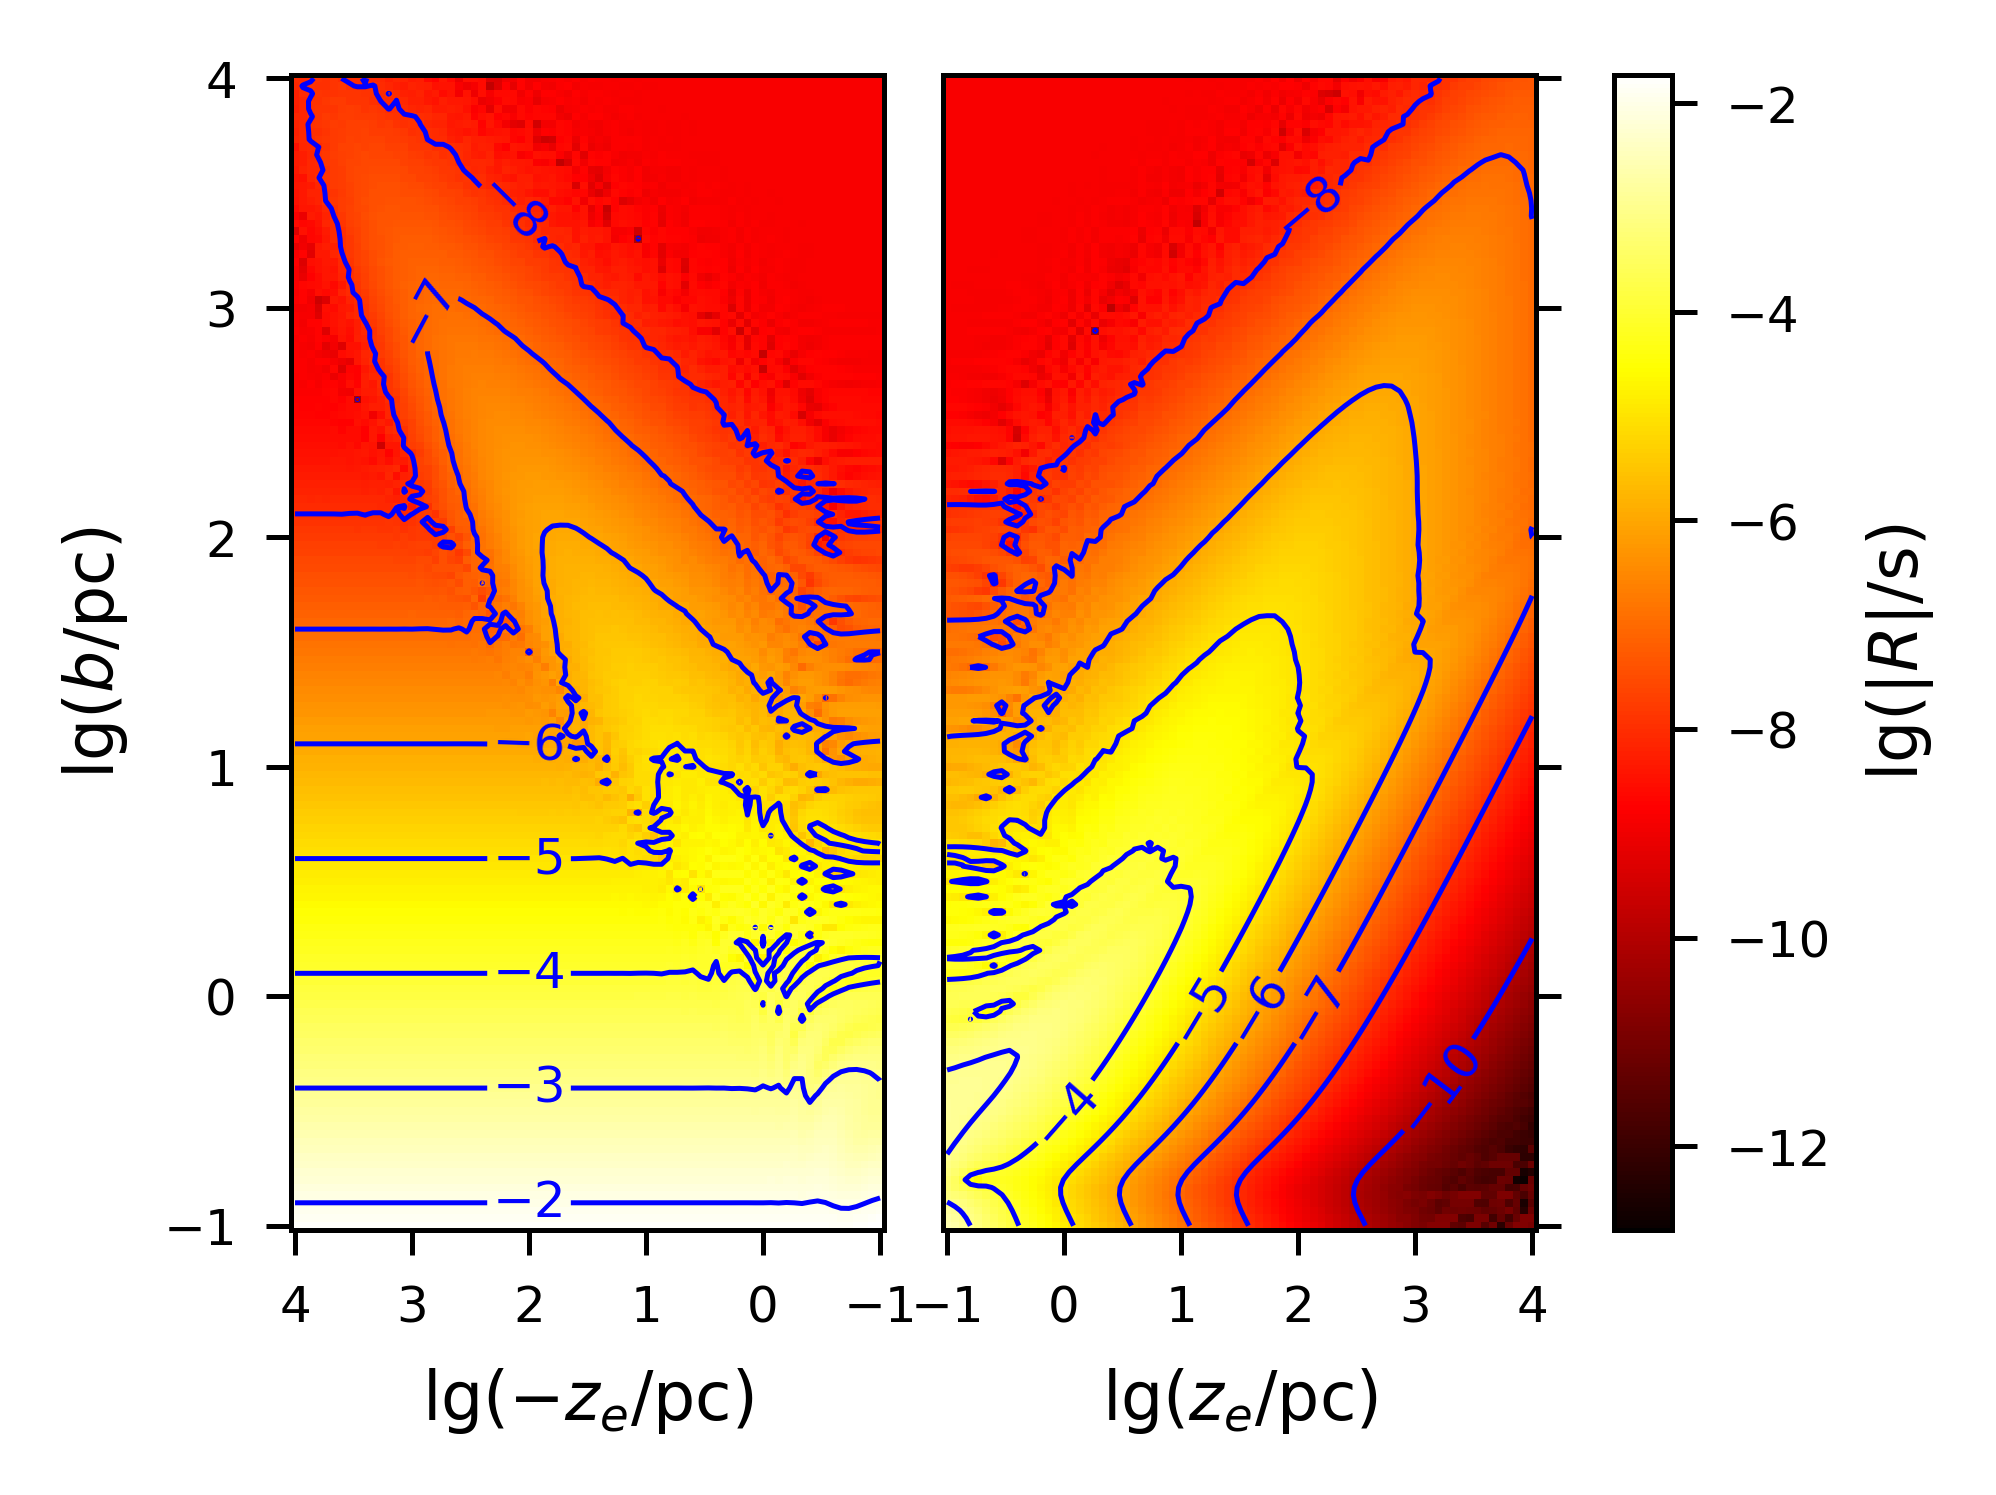

In [55]:
zsep=pd.read_csv(os.path.join(data_dir, 'zsepm31.csv'),header=None)
bsep=pd.read_csv(os.path.join(data_dir, 'bsepm31.csv'),header=None)
rmR=pd.read_csv(os.path.join(data_dir, 'rmRm31.csv'),header=None)
rmL=pd.read_csv(os.path.join(data_dir, 'rmLm31.csv'),header=None)

Zsep,Bsep=np.meshgrid(zsep,bsep,indexing="ij")

fig,(ax1,ax2)=plt.subplots(1,2,gridspec_kw={'wspace': 0.1})

vmin = np.min([rmL.values.min(), rmR.values.min()])
vmax = np.max([rmL.values.max(), rmR.values.max()])
norm = plt.Normalize(vmin=vmin, vmax=vmax)

im2 = ax2.pcolormesh(Zsep, Bsep, rmR, cmap="hot", norm=norm)
im1 = ax1.pcolormesh(Zsep, Bsep, rmL, cmap="hot", norm=norm)
ax1.invert_xaxis()

cbar = fig.colorbar(im1, ax=[ax1, ax2],location='right')
for ax in fig.get_axes():
    ax.label_outer()

ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

cs1=ax1.contour(Zsep,Bsep,rmL,colors="blue",linestyles="solid",levels=[-10,-8,-7,-6,-5,-4,-3,-2,-1,0])
cs2=ax2.contour(Zsep,Bsep,rmR,colors="blue",linestyles="solid",levels=[-10,-8,-7,-6,-5,-4,-3,-2,-1,0])
manual_Locations=[
    (2,3.5),
    (2,0),
    (2,0.5),
    (3,3),
    (2,1),
    (2,-0.4),
    (2,-0.8)
]
ax1.clabel(cs1,fontsize=label_font_size,manual=manual_Locations)
manual_Locations=[
    (0,-0.5),
    (1,0),
    (1.5,0),
    (2,0),
    (2,3.5),
    (3.5,-0.5)
]
ax2.clabel(cs2,fontsize=label_font_size,manual=manual_Locations)

ax1.xaxis.set_major_locator(MaxNLocator(6))  # x轴最多10个主刻度
ax2.xaxis.set_major_locator(MaxNLocator(6))  # 右侧图同样设置

#plt.subplots_adjust(wspace=0.2)   
ax1.set_xlabel(r'$\lg(-z_e/\mathrm{pc})$')
ax1.set_ylabel(r'$\lg(b/\mathrm{pc})$')
ax2.set_xlabel(r'$\lg(z_e/\mathrm{pc})$')
cbar.set_label(r'$\lg(|R|/\mathrm{s})$')
plt.legend(frameon=False)
plt.savefig(os.path.join(figure_dir, 'M31_3yr_q001.pdf'))
plt.show()

**E. Phase Distribution**

C:\Users\qihou\AppData\Local\Temp\ipykernel_16660\2482789254.py:12: UserWarning: Adding colorbar to a different Figure <Figure size 2007.9x1500 with 2 Axes> than <Figure size 2007.9x1500 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(im2, location='right')
C:\Users\qihou\AppData\Local\Temp\ipykernel_16660\2482789254.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


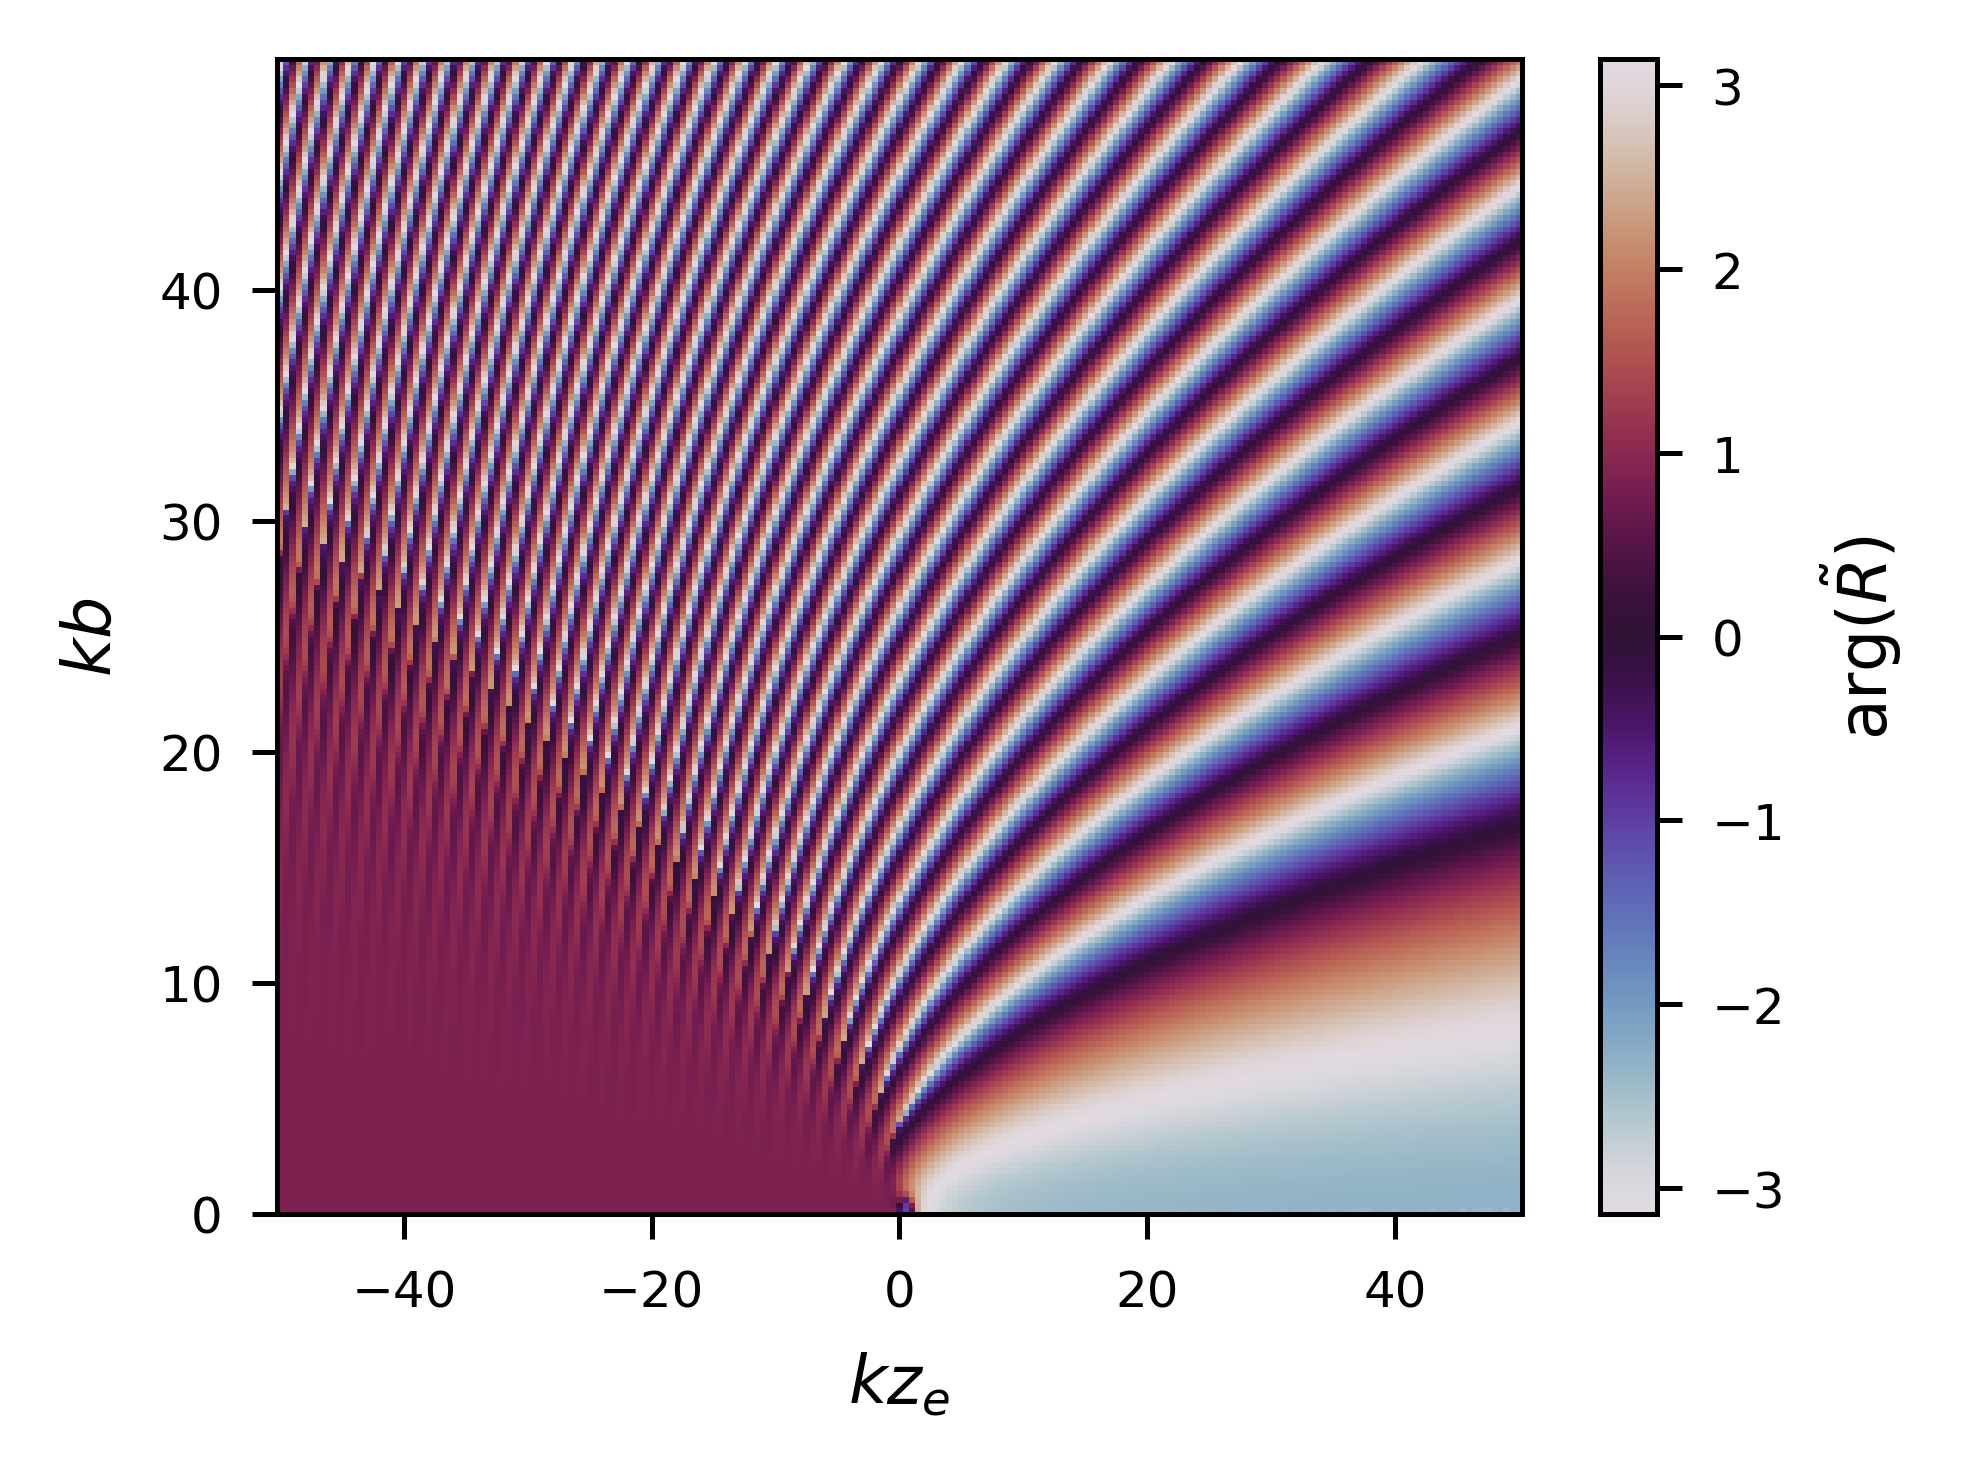

In [56]:
kzsep=pd.read_csv(os.path.join(data_dir, 'kzsepphase.csv'),header=None)
kbsep=pd.read_csv(os.path.join(data_dir, 'kbsepphase.csv'),header=None)
phase=pd.read_csv(os.path.join(data_dir, 'phase.csv'),header=None)


KZsep,KBsep=np.meshgrid(kzsep,kbsep,indexing="ij")


im2 = plt.pcolormesh(KZsep, KBsep, phase, cmap="twilight")


cbar = fig.colorbar(im2, location='right')




#plt.subplots_adjust(wspace=0.2)   
plt.xlabel(r'$kz_e$')
plt.ylabel(r'$kb$')
cbar.set_label(r'$\arg(\tilde{R})$')
plt.legend(frameon=False)
plt.savefig(os.path.join(figure_dir, 'Phase.pdf'))

plt.show()

**F. Comparison**

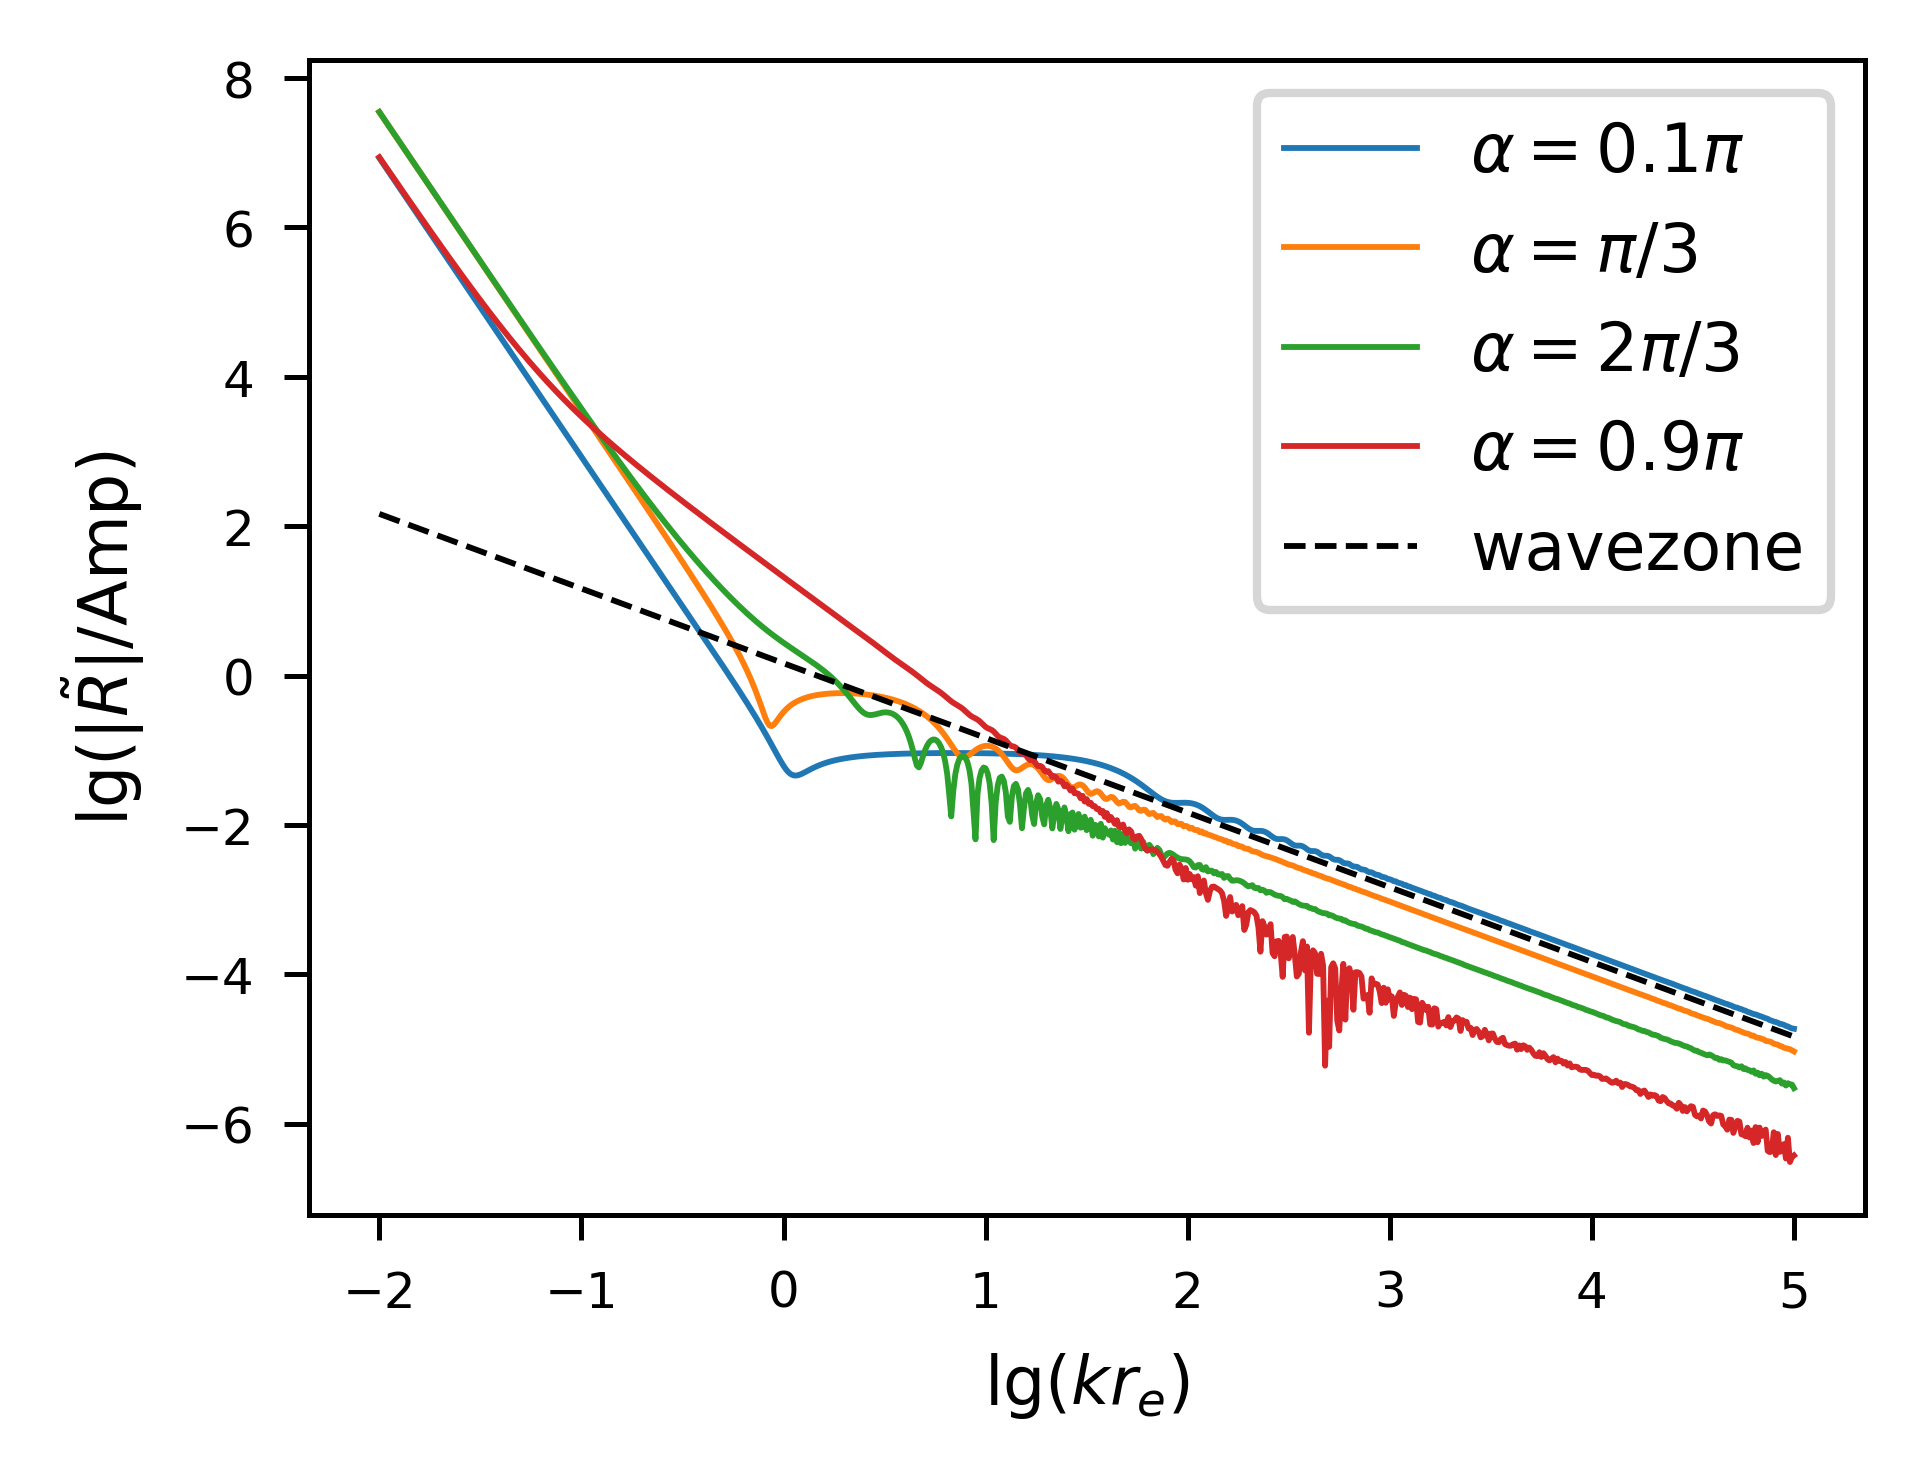

In [57]:
rg=pd.read_csv(os.path.join(data_dir, 'rg.csv'),header=None)
r0=pd.read_csv(os.path.join(data_dir, 'r0.csv'),header=None)
r60=pd.read_csv(os.path.join(data_dir, 'r60.csv'),header=None)
r120=pd.read_csv(os.path.join(data_dir, 'r120.csv'),header=None)
r180=pd.read_csv(os.path.join(data_dir, 'r180.csv'),header=None)

x=rg[0].values    
y1=r0[1].values
y2=r60[1].values
y3=r120[1].values
y4=r180[1].values
yg=rg[1].values
plt.plot(x,y1,label=r'$\alpha=0.1\pi$',linewidth=0.7)
plt.plot(x,y2,label=r'$\alpha=\pi/3$',linewidth=0.7)
plt.plot(x,y3,label=r'$\alpha=2\pi/3$',linewidth=0.7)
plt.plot(x,y4,label=r'$\alpha=0.9\pi$',linewidth=0.7)
plt.plot(x,yg,linestyle='--',color='black',linewidth=0.7,label="wavezone")
plt.xlabel(r'$\lg(kr_e)$')
plt.ylabel(r'$\lg(|\tilde{R}|/\mathrm{Amp})$')
plt.legend()
plt.savefig(os.path.join(figure_dir, 'Comparison.pdf'))
plt.show()